In [ ]:
import pandas as pd
import json
import os

# folder = "C:/Users/.../Downloads/AIO_data_collection/google/A city in NE of US"
# results = []
# min_len=100000
# for filename in os.listdir(folder):
#     if filename.endswith("ai_overview.json"):
#         filepath = os.path.join(folder, filename)

#         with open(filepath, "r", encoding="utf-8") as f:
#             try:
#                 data = json.load(f)
#             except json.JSONDecodeError:
#                 print(f"Skipping invalid JSON: {filename}")
#                 continue
#         if len(str(data))<min_len:
#             min_len=len(str(data))
#             print(filepath,min_len)
#         elif len(str(data))<750:
#             print(filepath,len(str(data)))

In [ ]:
import pandas as pd
import json
import os


df=pd.read_csv('./AIO_Benchmark_Dataset_v1.csv')
# df['AIO_12_7_8']=False
# for i in df['ID']:
#     if os.path.exists(f"C:/Users/.../Downloads/AIO_data_collection/google/A city in NE of US/stratified_benchmark_test_{int(i)}_google_ai_overview.json"):
#         df.at[i-1,'AIO_12_7_8']=True

In [153]:
df.iloc[:5]

,Unnamed: 0,ID,query,dataset,label,AIO_12_7_8,has_keywords,length,length_2,length_z,length_z_bin,length_z_clipped
0,0,1,holidaytraditions,Amazon Retail,NaN,True,False,1,1,-1.849845,"(-3.4019999999999997, -1.384]",-1.849845
1,1,2,youtube camera for vlogging,Amazon Retail,NaN,True,False,4,4,0.199466,"(-0.0731, 0.367]",0.199466
2,2,3,picasso tiles,Amazon Retail,NaN,True,False,2,2,-1.166741,"(-1.384, -0.953]",-1.166741
3,3,4,electronic bug detector,Amazon Retail,NaN,True,False,3,3,-0.483637,"(-0.517, -0.27]",-0.483637
4,4,5,boxers for men,Amazon Retail,NaN,False,False,3,3,-0.483637,"(-0.517, -0.27]",-0.483637


In [154]:
from collections import Counter
Counter(df.AIO_12_7_8),7540/11500

(Counter({True: 7540, False: 3960}), 0.6556521739130434)

In [257]:
dataset_AIOs_p=df.groupby('dataset').mean('AIO_12_7_8')
dataset_AIOs_p

,Unnamed: 0,ID,AIO_12_7_8,has_keywords,length_2,length_z,length_z_clipped
dataset,,,,,,,
Amazon Retail,249.5,250.5,0.1740,0.0100,3.7080,-9.925394e-17,-0.001230
Amazon Retail Comp,1249.5,1250.5,0.8820,0.4120,8.8220,2.537970e-16,-0.004077
Amazon Retail Q,749.5,750.5,0.9200,1.0000,9.4900,-1.314504e-16,0.005734
Debate,4999.5,5000.5,0.9180,1.0000,8.1660,-1.801892e-16,-0.004058
ELI5,3999.5,4000.5,0.9460,1.0000,14.9550,-4.440892e-18,-0.012396
Localized,5999.5,6000.5,0.4880,0.0390,5.1930,3.443912e-16,-0.000931
NQ,1999.5,2000.5,0.8620,0.7770,9.3350,-4.804490e-16,-0.011117
NQ keywords,2999.5,3000.5,0.7650,0.0390,4.4320,-2.386980e-16,-0.005067
ORCAS,8999.5,9000.5,0.5146,0.1128,3.2366,-8.011369e-17,-0.005877


In [258]:
df.groupby('dataset').count()

,Unnamed: 0,ID,query,label,AIO_12_7_8,has_keywords,length,length_2,length_z,length_z_bin,length_z_clipped,ORCAS_high_label
dataset,,,,,,,,,,,,
Amazon Retail,500,500,500,0,500,500,500,500,500,500,500,500
Amazon Retail Comp,500,500,500,0,500,500,500,500,500,500,500,500
Amazon Retail Q,500,500,500,0,500,500,500,500,500,500,500,500
Debate,1000,1000,1000,0,1000,1000,1000,1000,1000,1000,1000,1000
ELI5,1000,1000,1000,0,1000,1000,1000,1000,1000,1000,1000,1000
Localized,1000,1000,1000,0,1000,1000,1000,1000,1000,1000,1000,1000
NQ,1000,1000,1000,0,1000,1000,1000,1000,1000,1000,1000,1000
NQ keywords,1000,1000,1000,0,1000,1000,1000,1000,1000,1000,1000,1000
ORCAS,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000


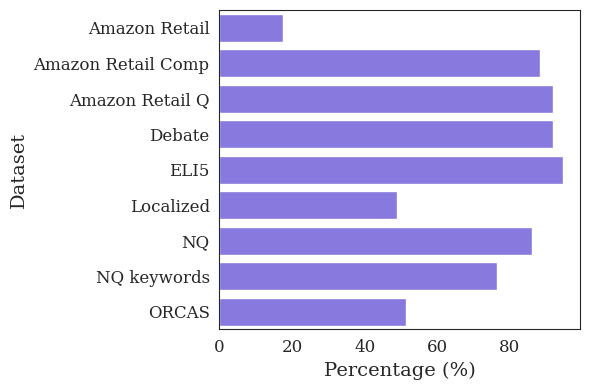

In [156]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data
data = {
    "dataset": [
        "Amazon Retail", "Amazon Retail Comp", "Amazon Retail Q",
        "Debate", "ELI5", "Localized", "NQ", "NQ keywords", "ORCAS"
    ],
    "percentage": [
        0.1740, 0.8820, 0.9200, 0.9180, 0.9460,
        0.4880, 0.8620, 0.7650, 0.5146
    ]
}

df2 = pd.DataFrame(data)
df2["percentage"] = df2["percentage"] * 100

sns.set_style("white")
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 10         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df2,
    x="percentage",
    y="dataset",
    orient="h",
    color='mediumslateblue'
)

plt.xlabel("Percentage (%)")
plt.ylabel("Dataset")
#plt.title("Percentage of Queries with AIO by Dataset")

plt.tight_layout()
plt.savefig('p_AIOs_by_dataset.pdf', format='pdf', dpi=1200)
plt.show()

In [157]:
df['ORCAS_high_label']='Informational'
for idx,row in df.iterrows():
    if row['label']=='Navigational':
        df.at[idx,'ORCAS_high_label']='Navigational'
    elif row['label']=='Transactional':
        df.at[idx,'ORCAS_high_label']='Transactional'
    else:
        continue
orcas_AIOs=df[df.dataset=='ORCAS'].groupby('ORCAS_high_label').count()['ID']
orcas_AIOs

ORCAS_high_label
Informational    4053
Navigational      758
Transactional     189
Name: ID, dtype: int64

In [158]:
orcas_AIOs_p=df[df.dataset=='ORCAS'].groupby('ORCAS_high_label').mean('AIO_12_7_8')
orcas_AIOs_p

,Unnamed: 0,ID,AIO_12_7_8,has_keywords,length_2,length_z,length_z_clipped
ORCAS_high_label,,,,,,,
Informational,8994.646435,8995.646435,0.582531,0.134715,3.402911,0.102882,0.095772
Navigational,9060.444591,9061.444591,0.182058,0.005277,2.137203,-0.680100,-0.680100
Transactional,8859.158730,8860.158730,0.391534,0.063492,4.079365,0.521345,0.518354


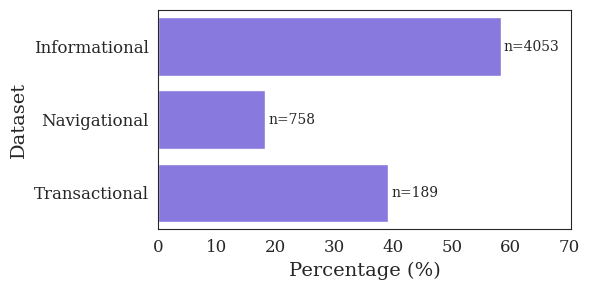

In [159]:
plt.figure(figsize=(6, 3))
ax=sns.barplot(
    data=orcas_AIOs_p,
    x=orcas_AIOs_p.AIO_12_7_8*100,
    y=orcas_AIOs_p.index,
    orient="h",
    color='mediumslateblue'
)

for i,dataset in enumerate(orcas_AIOs_p.index):
    n_val = orcas_AIOs.loc[dataset]
    ax.text(
        orcas_AIOs_p.loc[dataset]['AIO_12_7_8']*100 + 0.5,              # small offset to the right of the bar
        i,
        f"n={n_val}",
        va='center',
        fontsize=10
    )
ax.set_xlim(0, orcas_AIOs_p["AIO_12_7_8"].max()*100 + 12)
plt.xlabel("Percentage (%)")
plt.ylabel("Dataset")
#plt.title("Percentage of Queries with AIO by Query Type in ORCAS")

plt.tight_layout()
plt.show()


In [160]:
df[(df.label=='Abstain')&(df.AIO_12_7_8==True)]

,Unnamed: 0,ID,query,dataset,label,AIO_12_7_8,has_keywords,length,length_2,length_z,length_z_bin,length_z_clipped,ORCAS_high_label
6519,6519,6520,festivals this weekend,ORCAS,Abstain,True,False,3,3,-0.146364,"(-0.176, -0.146]",-0.146364,Informational
6524,6524,6525,accounting designations in canada,ORCAS,Abstain,True,False,4,4,0.472248,"(0.367, 0.472]",0.472248,Informational
6525,6525,6526,math practice sites,ORCAS,Abstain,True,False,3,3,-0.146364,"(-0.176, -0.146]",-0.146364,Informational
6528,6528,6529,good gamertags for xbox,ORCAS,Abstain,True,False,4,4,0.472248,"(0.367, 0.472]",0.472248,Informational
6560,6560,6561,natural water pills for fluid retention,ORCAS,Abstain,True,False,6,6,1.709473,"(1.702, 13.463]",1.709473,Informational
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11475,11475,11476,frequent flyer american airlines,ORCAS,Abstain,True,False,4,4,0.472248,"(0.367, 0.472]",0.472248,Informational
11484,11484,11485,zinc benefits for women,ORCAS,Abstain,True,False,4,4,0.472248,"(0.367, 0.472]",0.472248,Informational
11487,11487,11488,yellow watermelon,ORCAS,Abstain,True,False,2,2,-0.764976,"(-0.953, -0.765]",-0.764976,Informational
11497,11497,11498,birthday word,ORCAS,Abstain,True,False,2,2,-0.764976,"(-0.953, -0.765]",-0.764976,Informational


In [161]:
localized_qs=df[df.dataset=='Localized'].reset_index(drop=True)
localized_qs['location']=None
for idx,i in enumerate(localized_qs['query'].str.split('near')):
    if 'me' in i[1]:
        localized_qs.at[idx,'location']='Near Me'
    elif 'Shanghai' in i[1]:
        localized_qs.at[idx,'location']='Near Shanghai'
    elif 'Colorado' in i[1]:
        localized_qs.at[idx,'location']='Near Boulder'
    elif 'Spain' in i[1]:
        localized_qs.at[idx,'location']='Near Alicante'

In [162]:
local_AIOs=localized_qs.groupby('location').mean('AIO_12_7_8')
local_AIOs

,Unnamed: 0,ID,AIO_12_7_8,has_keywords,length_2,length_z,length_z_clipped
location,,,,,,,
Near Alicante,6374.345382,6375.345382,0.393574,0.036145,5.582329,0.354381,0.352513
Near Boulder,6124.415323,6125.415323,0.620968,0.048387,5.649194,0.415244,0.413368
Near Me,5629.570866,5630.570866,0.307087,0.047244,4.783465,-0.372774,-0.372774
Near Shanghai,5874.331967,5875.331967,0.635246,0.024590,4.758197,-0.395774,-0.395774


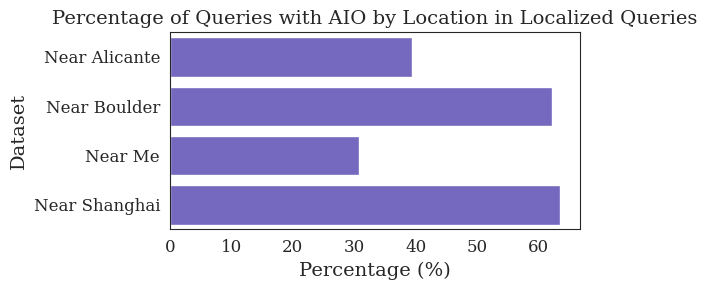

In [163]:
plt.figure(figsize=(6, 3))
sns.barplot(
    data=local_AIOs,
    x=local_AIOs.AIO_12_7_8*100,
    y=local_AIOs.index,
    orient="h",
    color='slateblue'
)


plt.xlabel("Percentage (%)")
plt.ylabel("Dataset")
plt.title("Percentage of Queries with AIO by Location in Localized Queries")

plt.tight_layout()
plt.show()

In [164]:
def contains_keywords(text, keywords):
    """Return True if any keyword appears in the text (case-insensitive)."""
    if not isinstance(text, str):
        return False
    text_lower = text.lower()
    return any(kw.lower() in text_lower for kw in keywords)

keywords = [
    "what", "who", "whom", "whose", "which",
    "when", "where", "why", "how","?"
]

df["has_keywords"] = df["query"].apply(lambda x: contains_keywords(x, keywords))

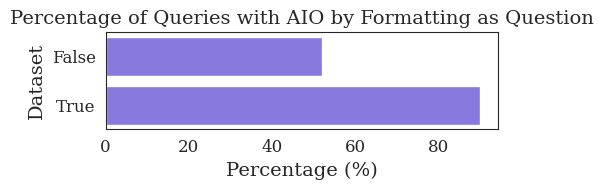

In [165]:
Counter(df.has_keywords)
q_AIOs=df.groupby('has_keywords').mean('AIO_12_7_8')
q_AIOs
plt.figure(figsize=(5, 2))
sns.barplot(
    x=q_AIOs.AIO_12_7_8*100,
    y=q_AIOs.index,
    orient="h",
    color='mediumslateblue'
)


plt.xlabel("Percentage (%)")
plt.ylabel("Dataset")
plt.title("Percentage of Queries with AIO by Formatting as Question")

plt.tight_layout()
plt.show()

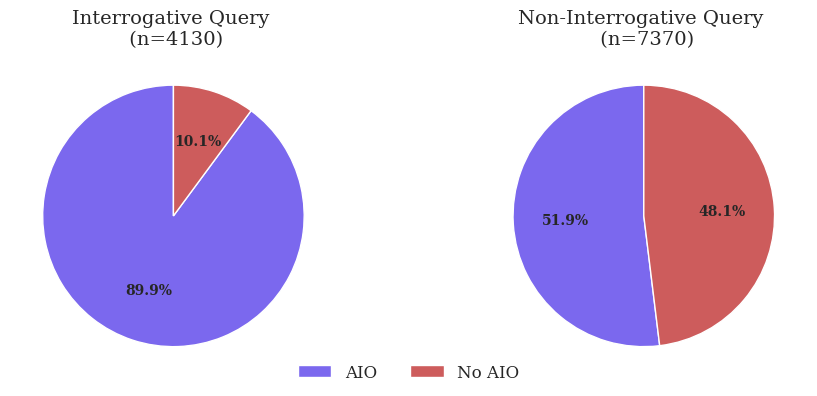

In [166]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 10         # Set the font size
plt.rcParams['font.weight'] = 'bold' 
# Split data
df_false = df[df['has_keywords'] == False]
df_true = df[df['has_keywords'] == True]

# Percentages
vals_false = [
    df_false['AIO_12_7_8'].mean(),
    1 - df_false['AIO_12_7_8'].mean()
]

vals_true = [
    df_true['AIO_12_7_8'].mean(),
    1 - df_true['AIO_12_7_8'].mean()
]

labels = ['AIO', 'No AIO']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

wedges0, _,_=axes[0].pie(
    vals_true,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=['mediumslateblue', 'indianred']
)
axes[0].set_title(f'Interrogative Query \n (n={len(df_true)})')

wedges1, _,_=axes[1].pie(
    vals_false,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=['mediumslateblue', 'indianred']
)
axes[1].set_title(f'Non-Interrogative Query \n (n={len(df_false)})')
plt.rcParams['font.weight'] = 'medium'
fig.legend(
    wedges0,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False
)

#plt.suptitle('AIO Presence by Keyword Formatting', y=1.05)
plt.tight_layout()
plt.show()

In [167]:
def query_length(text):
    """Return True if any keyword appears in the text (case-insensitive)."""
    if not isinstance(text, str):
        return False
    text_lower = text.lower()
    if len(text_lower.split())<10:
        return len(text_lower.split())
    else:
        return '10+'


df["length"] = df["query"].apply(lambda x: query_length(x))

length_counter=Counter(df.length)
length_counter

Counter({3: 1756,
         '10+': 1709,
         4: 1651,
         5: 1370,
         2: 1286,
         8: 973,
         6: 847,
         9: 665,
         1: 636,
         7: 607})

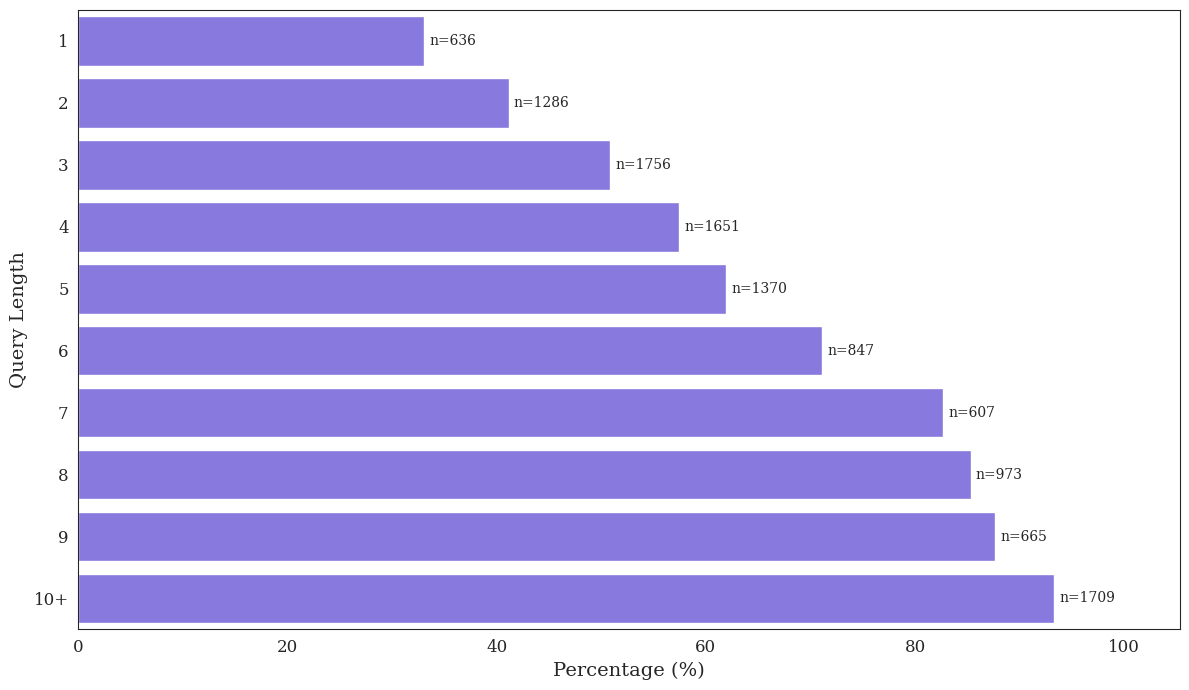

In [168]:
Counter(df.has_keywords)
len_AIOs=df.groupby('length').mean('AIO_12_7_8')
len_AIOs
plt.figure(figsize=(12, 7))
ax=sns.barplot(
    x=len_AIOs.AIO_12_7_8*100,
    y=len_AIOs.index,
    color='mediumslateblue'
)


for i,dataset in enumerate(len_AIOs.index):
    n_val = length_counter[dataset]
    ax.text(
        len_AIOs.loc[dataset]['AIO_12_7_8']*100 + 0.5,              # small offset to the right of the bar
        i,
        f"n={n_val}",
        va='center',
        fontsize=10
    )
ax.set_xlim(0, len_AIOs.AIO_12_7_8.max()*100 + 12)

plt.xlabel("Percentage (%)")
plt.ylabel("Query Length")
#plt.title("Percentage of Queries with AIO by Query Length")

plt.tight_layout()
plt.show()

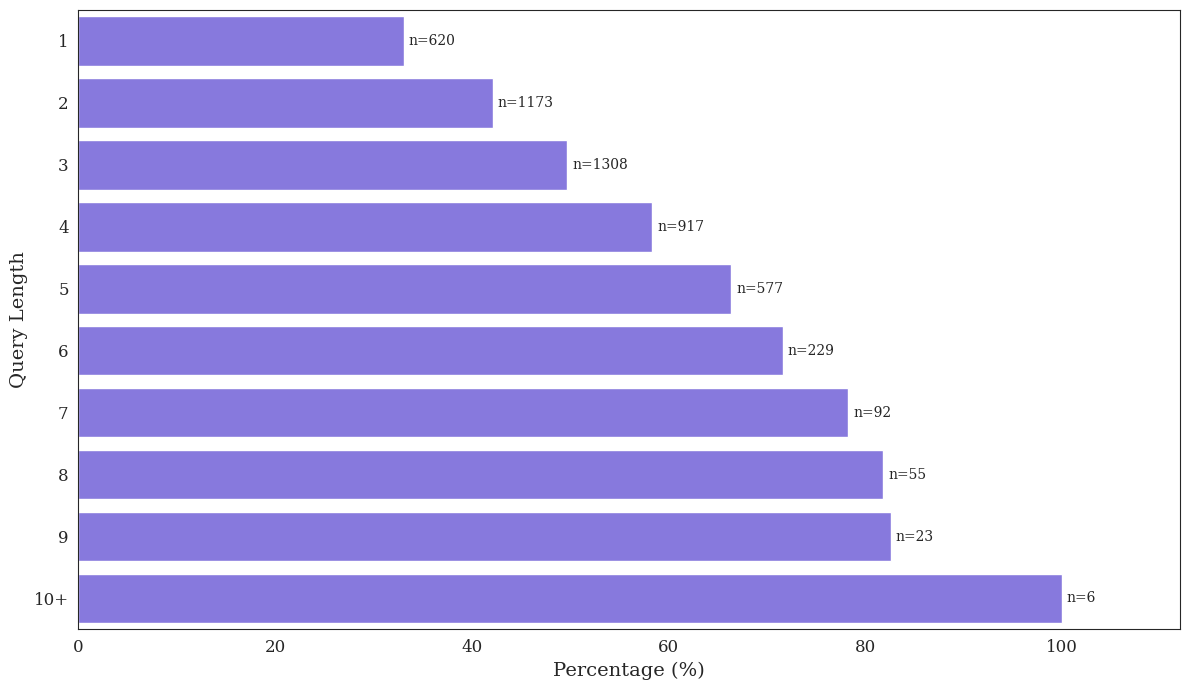

In [169]:

length_counter2=Counter(df[df.dataset=='ORCAS'].length)
length_counter
len_AIOs=df[df.dataset=='ORCAS'].groupby('length').mean('AIO_12_7_8')
len_AIOs
plt.figure(figsize=(12, 7))
ax=sns.barplot(
    x=len_AIOs.AIO_12_7_8*100,
    y=len_AIOs.index,
    color='mediumslateblue'
)


for i,dataset in enumerate(len_AIOs.index):
    n_val = length_counter2[dataset]
    ax.text(
        len_AIOs.loc[dataset]['AIO_12_7_8']*100 + 0.5,              # small offset to the right of the bar
        i,
        f"n={n_val}",
        va='center',
        fontsize=10
    )
ax.set_xlim(0, len_AIOs.AIO_12_7_8.max()*100 + 12)

plt.xlabel("Percentage (%)")
plt.ylabel("Query Length")
#plt.title("Percentage of ORCAS Queries with AIO by Query Length")

plt.tight_layout()
plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_48312\626191023.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  z_AIOs = df.groupby("length_z_bin").mean(numeric_only=True)["AIO_12_7_8"]


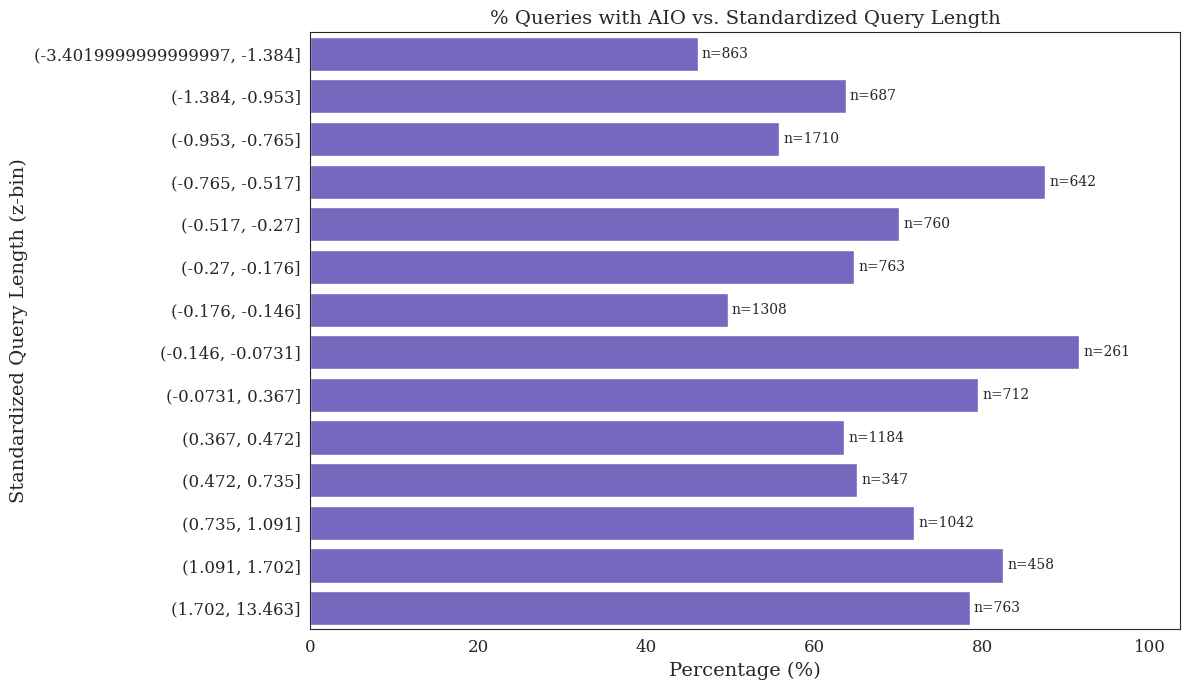

In [170]:
def query_length(text):
    """Return True if any keyword appears in the text (case-insensitive)."""
    if not isinstance(text, str):
        return False
    text_lower = text.lower()
    return len(text_lower.split())



df["length_2"] = df["query"].apply(lambda x: query_length(x))


df["length_z"] = df.groupby("dataset")["length_2"].transform(
    lambda x: (x - x.mean()) / x.std()
)
df["length_z_bin"] = pd.qcut(
    df["length_z"],
    q=15,
    duplicates="drop"   # handles ties perfectly
)
z_AIOs = df.groupby("length_z_bin").mean(numeric_only=True)["AIO_12_7_8"]
z_counts = df["length_z_bin"].value_counts().sort_index()

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=z_AIOs.values * 100,
    y=z_AIOs.index.astype(str),
    color="slateblue"
)

# Add sample size labels
for i, bin_label in enumerate(z_AIOs.index):
    n_val = z_counts[bin_label]
    ax.text(
        z_AIOs[bin_label] * 100 + 0.5,
        i,
        f"n={n_val}",
        va='center',
        fontsize=10
    )

ax.set_xlim(0, z_AIOs.max() * 100 + 12)
plt.xlabel("Percentage (%)")
plt.ylabel("Standardized Query Length (z-bin)")
plt.title("% Queries with AIO vs. Standardized Query Length")

plt.tight_layout()
plt.show()

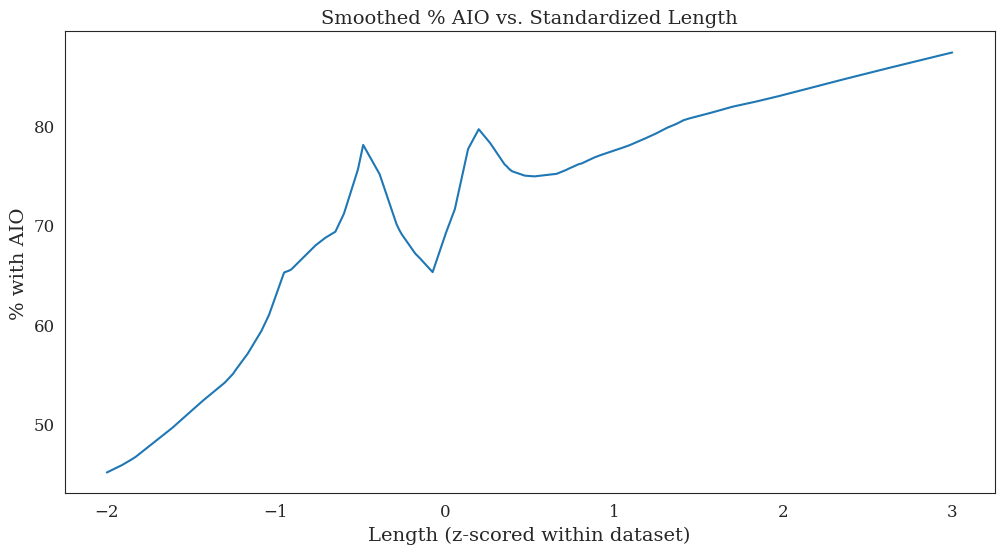

In [171]:
from statsmodels.nonparametric.smoothers_lowess import lowess
df["length_z_clipped"] = df["length_z"].clip(-2, 3)
smooth = lowess(
    df["AIO_12_7_8"], 
    df["length_z_clipped"], 
    frac=0.35
)

plt.figure(figsize=(12,6))
plt.plot(smooth[:,0], smooth[:,1] * 100)
plt.xlabel("Length (z-scored within dataset)")
plt.ylabel("% with AIO")
plt.title("Smoothed % AIO vs. Standardized Length")
plt.show()

In [ ]:
# df.to_csv('C:/Users/.../Downloads/AIO_Benchmark_Dataset_v1.csv')

In [ ]:
# import pandas as pd
# import json
# import os

# with open('C:/Users/.../Downloads/AIO_data_collection/google/A city in NE of US/stratified_benchmark_test_4486_google_ai_overview.json', "r", encoding="utf-8") as f:
#     data = json.load(f)
#     print(data)
#     print(len(str(data)))

<Figure size 2400x1500 with 0 Axes>

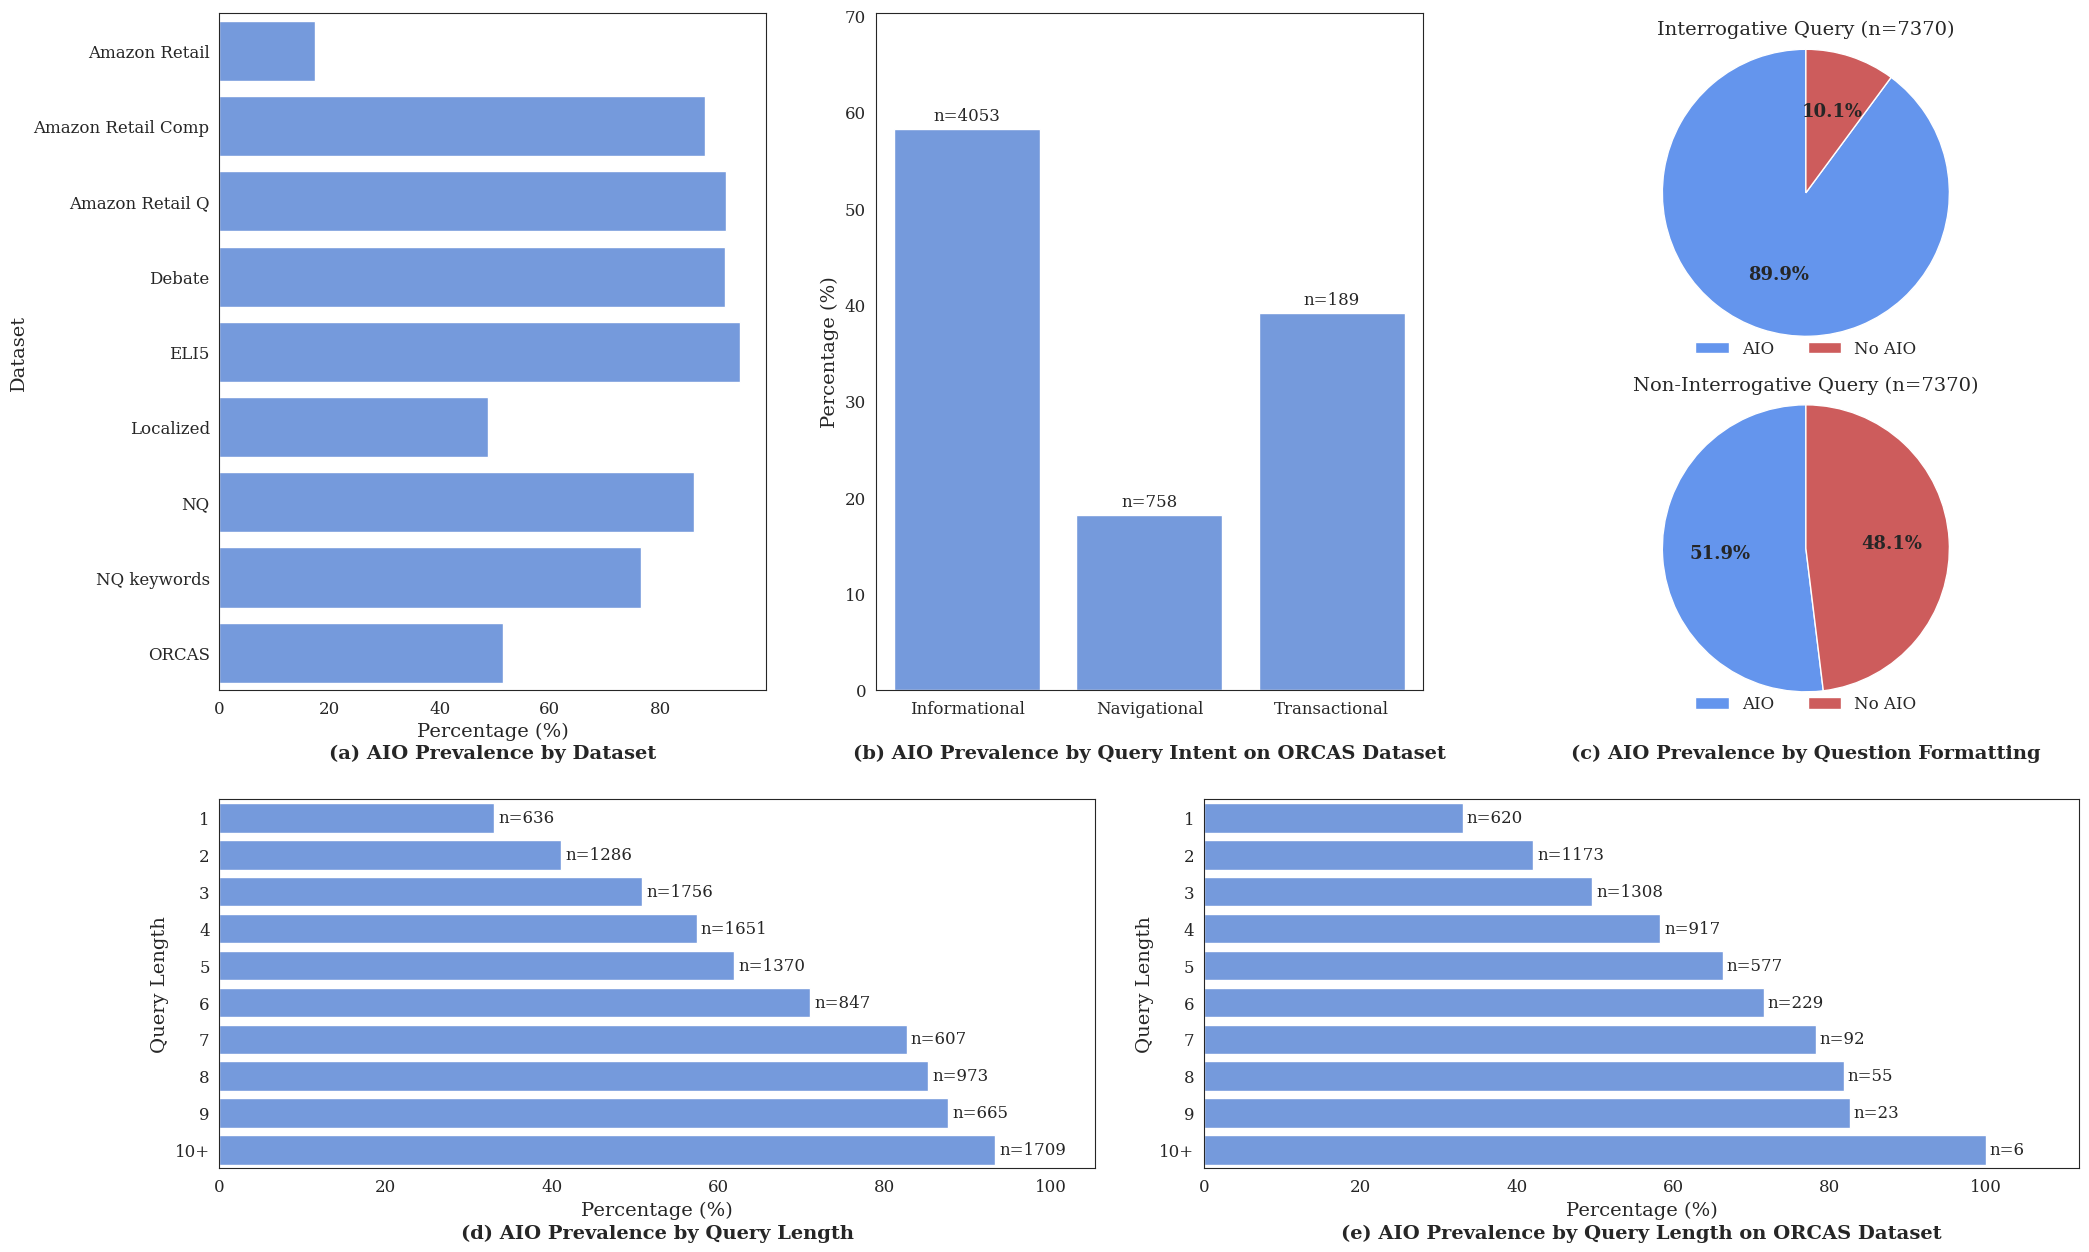

In [174]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(24, 15))
gs = gridspec.GridSpec(3, 6, hspace=0.35, wspace=0.5,height_ratios=[1,1,1.3])
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(24, 15))
gs = gridspec.GridSpec(3, 6, hspace=0.35, wspace=0.5,height_ratios=[1,1,1.3])

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,         # base font size
    'axes.titlesize': 14,    # axes titles
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 12,   # x tick labels
    'ytick.labelsize': 12,   # y tick labels
    'legend.fontsize': 12,   # legend text
})

# Top row (3 plots)
ax1 = fig.add_subplot(gs[0:2, 0:2])
ax2 = fig.add_subplot(gs[0:2, 2:4])
ax3 = fig.add_subplot(gs[0:1, 4:6])
ax3b = fig.add_subplot(gs[1:2, 4:6])

# Bottom row (2 centered plots)
ax4 = fig.add_subplot(gs[2:3, 0:3])
ax5 = fig.add_subplot(gs[2:3, 3:6])

pos = ax3b.get_position()  # returns Bbox(x0, y0, x1, y1)
new_pos = [pos.x0, pos.y0-0.025, pos.width, pos.height+0.05]  # lower by 0.05
ax3b.set_position(new_pos)

pos = ax3.get_position()  # returns Bbox(x0, y0, x1, y1)
new_pos = [pos.x0, pos.y0-0.05, pos.width, pos.height+0.05]  # lower by 0.05
ax3.set_position(new_pos)




ax=ax1
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 12         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
data = {
    "dataset": [
        "Amazon Retail", "Amazon Retail Comp", "Amazon Retail Q",
        "Debate", "ELI5", "Localized", "NQ", "NQ keywords", "ORCAS"
    ],
    "percentage": [
        0.1740, 0.8820, 0.9200, 0.9180, 0.9460,
        0.4880, 0.8620, 0.7650, 0.5146
    ]
}

df2 = pd.DataFrame(data)
df2["percentage"] = df2["percentage"] * 100

sns.set_style("white")
#plt.figure(figsize=(6, 4))
sns.barplot(
    data=df2,
    x="percentage",
    y="dataset",
    orient="h",
    color='cornflowerblue',
    ax=ax
)

ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Dataset")

ax1.text(
    0.5,                  # x position (center)
    -0.08,                # y position (below axes, negative moves below)
    "(a) AIO Prevalence by Dataset",
    transform=ax1.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='bold',      # bold text
    fontsize=14,
    family='serif'
)



ax=ax2
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 12         # Set the font size
plt.rcParams['font.weight'] = 'medium'
sns.barplot(
    data=orcas_AIOs_p,
    y=orcas_AIOs_p.AIO_12_7_8*100,
    x=orcas_AIOs_p.index,
    #orient="v",
    color='cornflowerblue',
    ax=ax
)

for i,dataset in enumerate(orcas_AIOs_p.index):
    n_val = orcas_AIOs.loc[dataset]
    ax.text(
        i,             # small offset to the right of the bar
        orcas_AIOs_p.loc[dataset]['AIO_12_7_8']*100+0.5,
        f"n={n_val}",
        ha='center',
        va='bottom',
        fontsize=12
    )
ax.set_ylim(0, orcas_AIOs_p["AIO_12_7_8"].max()*100 + 12)
ax.set_xlabel("")
ax.set_ylabel("Percentage (%)")


ax.text(
    0.5,                  # x position (center)
    -0.08,                # y position (below axes, negative moves below)
    "(b) AIO Prevalence by Query Intent on ORCAS Dataset",
    transform=ax.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='bold',      # bold text
    fontsize=14
)








ax=ax3
df_false = df[df['has_keywords'] == False]
df_true = df[df['has_keywords'] == True]

# Percentages
vals_false = [
    df_false['AIO_12_7_8'].mean(),
    1 - df_false['AIO_12_7_8'].mean()
]

vals_true = [
    df_true['AIO_12_7_8'].mean(),
    1 - df_true['AIO_12_7_8'].mean()
]

labels = ['AIO', 'No AIO']
#ax3, axes = plt.subplots(2, 1)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 13 
wedges0, _,_=ax3.pie(
    vals_true,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=['cornflowerblue', 'indianred']
)
plt.rcParams['font.weight'] = 'medium'
#ax3.set_title(f'Interrogative Query \n (n={len(df_true)})')
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 13 
wedges1, _,_=ax3b.pie(
    vals_false,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=['cornflowerblue', 'indianred']
)
plt.rcParams['font.weight'] = 'medium'
#ax3b.set_title(f'Non-Interrogative Query \n (n={len(df_false)})')
plt.rcParams['font.weight'] = 'medium'
ax3.legend(
    wedges0,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False
)

ax3b.legend(
    wedges0,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False
)

ax3.text(
    0.5,                  # x position (center)
    0.98,                # y position (below axes, negative moves below)
    f'Interrogative Query (n={len(df_false)})',
    transform=ax3.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='medium',      # bold text
    fontsize=14
)


ax3b.text(
    0.5,                  # x position (center)
    0.98,                # y position (below axes, negative moves below)
    f'Non-Interrogative Query (n={len(df_false)})',
    transform=ax3b.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='medium',      # bold text
    fontsize=14
)

ax3b.text(
    0.5,                  # x position (center)
    -0.045,                # y position (below axes, negative moves below)
    "(c) AIO Prevalence by Question Formatting",
    transform=ax3b.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='bold',      # bold text
    fontsize=14
)









ax=ax4
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 12         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
length_counter=Counter(df.length)
length_counter
len_AIOs=df.groupby('length').mean('AIO_12_7_8')
len_AIOs
#plt.figure(figsize=(12, 7))
sns.barplot(
    x=len_AIOs.AIO_12_7_8*100,
    y=len_AIOs.index,
    color='cornflowerblue',
    ax=ax
)


for i,dataset in enumerate(len_AIOs.index):
    n_val = length_counter[dataset]
    ax.text(
        len_AIOs.loc[dataset]['AIO_12_7_8']*100 + 0.5,              # small offset to the right of the bar
        i,
        f"n={n_val}",
        va='center',
        fontsize=12
    )
ax.set_xlim(0, len_AIOs.AIO_12_7_8.max()*100 + 12)

ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Query Length")
ax.text(
    0.5,                  # x position (center)
    -0.15,                # y position (below axes, negative moves below)
    "(d) AIO Prevalence by Query Length",
    transform=ax.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='bold',      # bold text
    fontsize=14
)


ax=ax5
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 12         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
length_counter2=Counter(df[df.dataset=='ORCAS'].length)
length_counter
len_AIOs=df[df.dataset=='ORCAS'].groupby('length').mean('AIO_12_7_8')
len_AIOs
#plt.figure(figsize=(12, 7))
sns.barplot(
    x=len_AIOs.AIO_12_7_8*100,
    y=len_AIOs.index,
    color='cornflowerblue',
    ax=ax
)


for i,dataset in enumerate(len_AIOs.index):
    n_val = length_counter2[dataset]
    ax.text(
        len_AIOs.loc[dataset]['AIO_12_7_8']*100+0.5,              # small offset to the right of the bar
        i,
        f"n={n_val}",
        va='center',
        fontsize=12
    )
ax.set_xlim(0, len_AIOs.AIO_12_7_8.max()*100 + 12)

ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Query Length")
ax.text(
    0.5,                  # x position (center)
    -0.15,                # y position (below axes, negative moves below)
    "(e) AIO Prevalence by Query Length on ORCAS Dataset",
    transform=ax.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='bold',      # bold text
    fontsize=14
)
#plt.title("Percentage of ORCAS Queries with AIO by Query Length")

#plt.tight_layout()
#plt.show()

# Save as single PDF
plt.savefig("five_panel_figure.pdf", bbox_inches="tight")
plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_48312\2743286403.py:304: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig("five_panel_figure.pdf", bbox_inches="tight")
C:\Users\micha\AppData\Local\Temp\ipykernel_48312\2743286403.py:304: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig("five_panel_figure.pdf", bbox_inches="tight")
C:\Users\micha\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


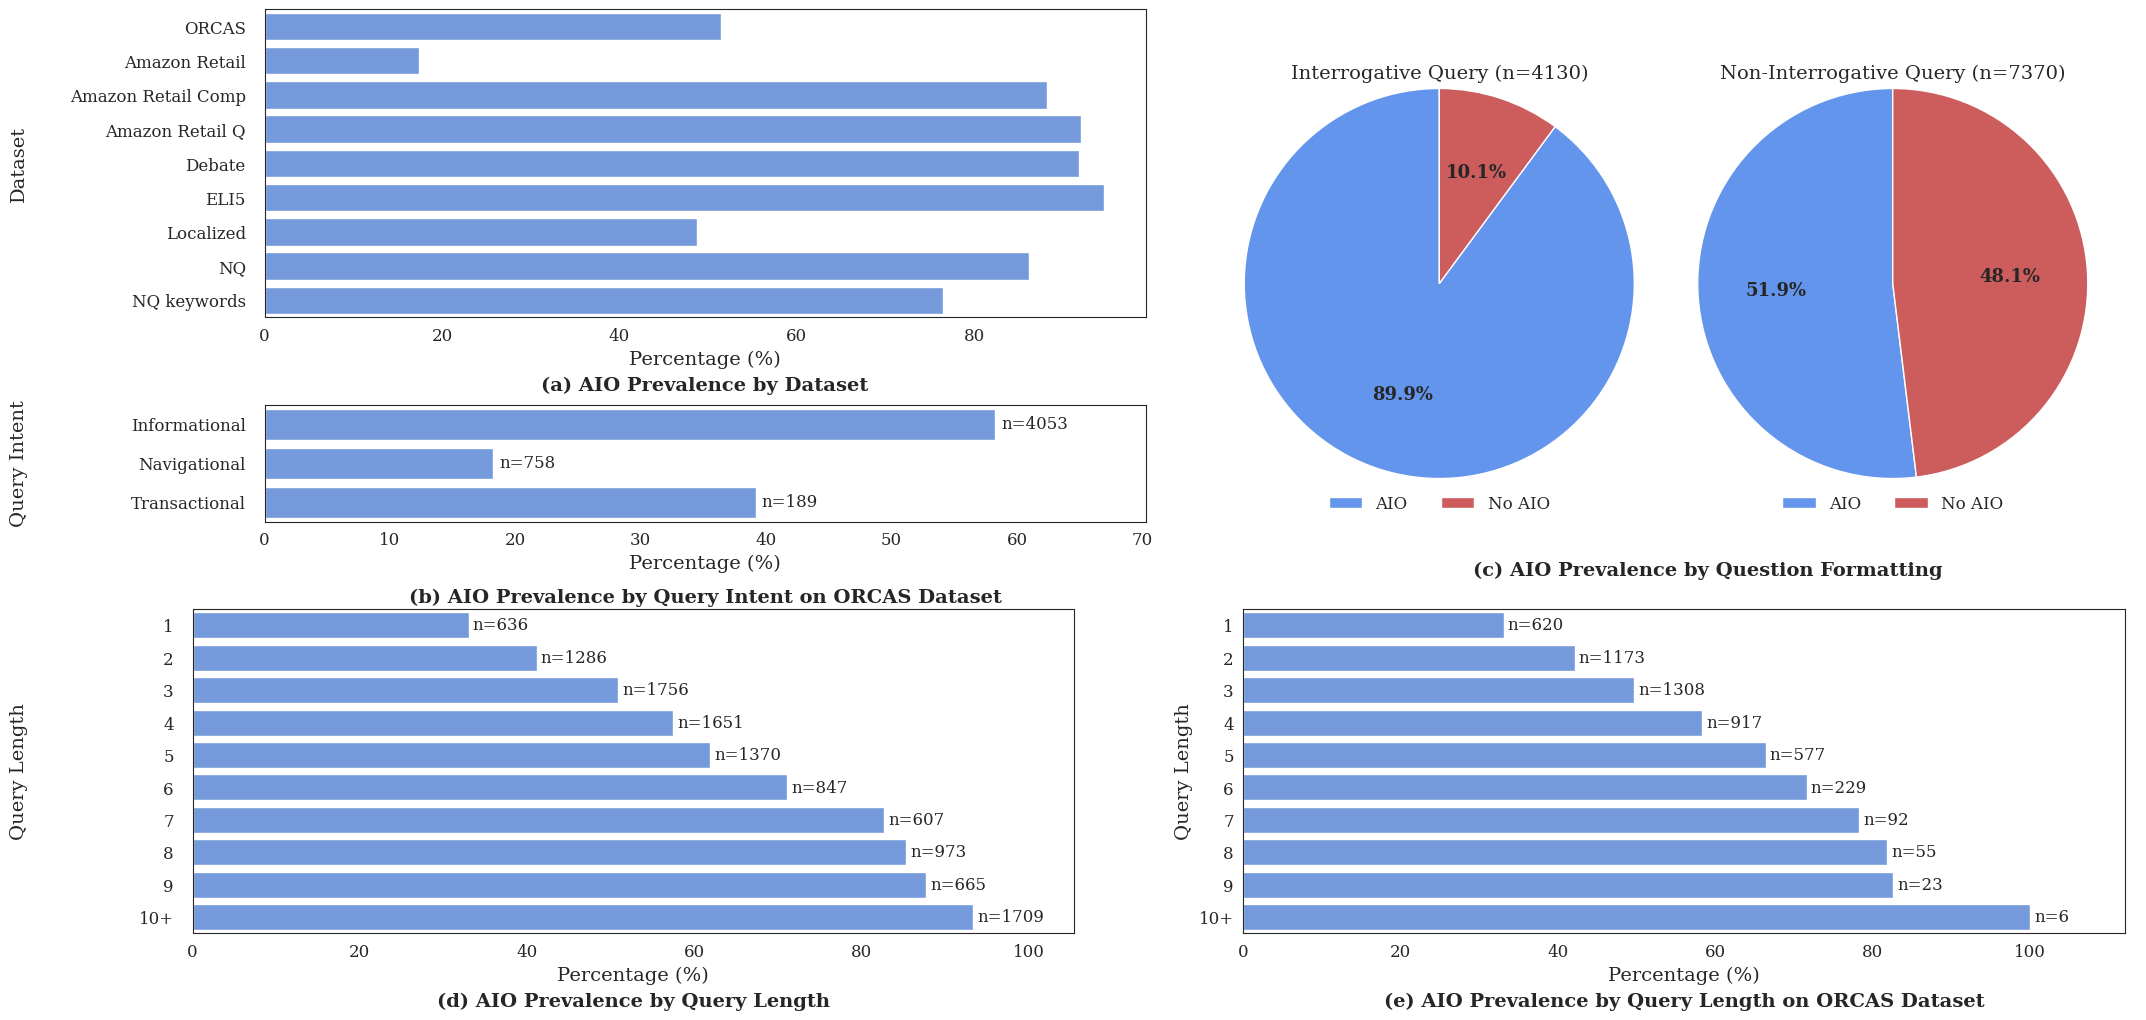

In [199]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(24, 12), layout="constrained")
gs = gridspec.GridSpec(3, 12, hspace=0.35, wspace=1.5,height_ratios=[0.95,0.36,1])

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,         # base font size
    'axes.titlesize': 14,    # axes titles
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 12,   # x tick labels
    'ytick.labelsize': 12,   # y tick labels
    'legend.fontsize': 12,   # legend text
})

# Top row (3 plots)
ax1 = fig.add_subplot(gs[0:1, 0:6]) # top left, AIO prevalence by dataset
ax2 = fig.add_subplot(gs[1:2, 0:6]) # middle left
ax3 = fig.add_subplot(gs[0:2, 6:9]) # top right, left pie chart
ax3b = fig.add_subplot(gs[0:2, 9:12]) # top right, right pie chart

# Bottom row (2 centered plots)
ax4 = fig.add_subplot(gs[2:3, 0:6])
ax5 = fig.add_subplot(gs[2:3, 6:12])

# Apply consistent styling for floating labels
for ax in [ax1, ax2, ax4]:
    ax.set_ylabel(ax.get_ylabel(), labelpad=30) # Pushes the "Dataset" title further out
    ax.tick_params(axis='y', pad=10)             # Pushes the tick labels further out

pos = ax3b.get_position()  # returns Bbox(x0, y0, x1, y1)
new_pos = [pos.x0-0.035, pos.y0-0.04, pos.width+0.04, pos.height+0.05]  # lower by 0.05
ax3b.set_position(new_pos)

pos = ax3.get_position()  # returns Bbox(x0, y0, x1, y1)
new_pos = [pos.x0-0.02, pos.y0-0.04, pos.width+0.04, pos.height+0.05]  # lower by 0.05
ax3.set_position(new_pos)

pos = ax4.get_position()  # returns Bbox(x0, y0, x1, y1)
new_pos = [pos.x0-0.03, pos.y0, pos.width, pos.height]  # lower by 0.05
ax4.set_position(new_pos)


ax=ax1
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 12         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
data = {
    "dataset": [
        "ORCAS", "Amazon Retail", "Amazon Retail Comp", "Amazon Retail Q",
        "Debate", "ELI5", "Localized", "NQ", "NQ keywords"
    ],
    "percentage": [
        0.5146, 0.1740, 0.8820, 0.9200, 0.9180, 0.9460,
        0.4880, 0.8620, 0.7650, 
    ]
}

df2 = pd.DataFrame(data)
df2["percentage"] = df2["percentage"] * 100

sns.set_style("white")
#plt.figure(figsize=(6, 4))
sns.barplot(
    data=df2,
    x="percentage",
    y="dataset",
    orient="h",
    color='cornflowerblue',
    ax=ax
)

ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Dataset")

ax1.text(
    0.5,                  # x position (center)
    -0.19,                # y position (below axes, negative moves below)
    "(a) AIO Prevalence by Dataset",
    transform=ax1.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='bold',      # bold text
    fontsize=14,
    family='serif'
)

ax=ax2
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 12         # Set the font size
plt.rcParams['font.weight'] = 'medium'
sns.barplot(
    data=orcas_AIOs_p,
    x=orcas_AIOs_p.AIO_12_7_8*100,
    y=orcas_AIOs_p.index,
    orient="h",
    color='cornflowerblue',
    ax=ax
)

for i,dataset in enumerate(orcas_AIOs_p.index):
    n_val = orcas_AIOs.loc[dataset]
    ax.text(
        orcas_AIOs_p.loc[dataset]['AIO_12_7_8']*100+0.5,             # small offset to the right of the bar
       i,
        f"n={n_val}",
        #ha='center',
        va='center',
        fontsize=12
    )
ax.set_xlim(0, orcas_AIOs_p["AIO_12_7_8"].max()*100 + 12)
ax.set_ylabel("Query Intent")
ax.set_xlabel("Percentage (%)")


ax.text(
    0.5,                  # x position (center)
    -0.57,                # y position (below axes, negative moves below)
    "(b) AIO Prevalence by Query Intent on ORCAS Dataset",
    transform=ax.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='bold',      # bold text
    fontsize=14
)

ax=ax3
df_false = df[df['has_keywords'] == False]
df_true = df[df['has_keywords'] == True]

# Percentages
vals_false = [
    df_false['AIO_12_7_8'].mean(),
    1 - df_false['AIO_12_7_8'].mean()
]

vals_true = [
    df_true['AIO_12_7_8'].mean(),
    1 - df_true['AIO_12_7_8'].mean()
]

labels = ['AIO', 'No AIO']
#ax3, axes = plt.subplots(2, 1)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 13 
wedges0, _,_=ax3.pie(
    vals_true,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=['cornflowerblue', 'indianred']
)
plt.rcParams['font.weight'] = 'medium'
#ax3.set_title(f'Interrogative Query \n (n={len(df_true)})')
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 13 
wedges1, _,_=ax3b.pie(
    vals_false,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=['cornflowerblue', 'indianred']
)
plt.rcParams['font.weight'] = 'medium'
#ax3b.set_title(f'Non-Interrogative Query \n (n={len(df_false)})')
plt.rcParams['font.weight'] = 'medium'
ax3.legend(
    wedges0,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False
)

ax3b.legend(
    wedges0,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False
)

ax3.text(
    0.5,                  # x position (center)
    0.95,                # y position (below axes, negative moves below)
    f'Interrogative Query (n={len(df_true)})',
    transform=ax3.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='medium',      # bold text
    fontsize=14
)


ax3b.text(
    0.5,                  # x position (center)
    0.95,                # y position (below axes, negative moves below)
    f'Non-Interrogative Query (n={len(df_false)})',
    transform=ax3b.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='medium',      # bold text
    fontsize=14
)

ax3b.text(
    0.12,                  # x position (center)
    -0.07,                # y position (below axes, negative moves below)
    "(c) AIO Prevalence by Question Formatting",
    transform=ax3b.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='bold',      # bold text
    fontsize=14
)

ax=ax4
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 12         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
length_counter=Counter(df.length)
length_counter
len_AIOs=df.groupby('length').mean('AIO_12_7_8')
len_AIOs
#plt.figure(figsize=(12, 7))
sns.barplot(
    x=len_AIOs.AIO_12_7_8*100,
    y=len_AIOs.index,
    color='cornflowerblue',
    ax=ax
)


for i,dataset in enumerate(len_AIOs.index):
    n_val = length_counter[dataset]
    ax.text(
        len_AIOs.loc[dataset]['AIO_12_7_8']*100 + 0.5,              # small offset to the right of the bar
        i,
        f"n={n_val}",
        va='center',
        fontsize=12
    )
ax.set_xlim(0, len_AIOs.AIO_12_7_8.max()*100 + 12)

ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Query Length")
ax.text(
    0.5,                  # x position (center)
    -0.18,                # y position (below axes, negative moves below)
    "(d) AIO Prevalence by Query Length",
    transform=ax.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='bold',      # bold text
    fontsize=14
)


ax=ax5
plt.rcParams['font.family'] = 'serif'  # Choose a font family like 'serif', 'sans-serif', etc.
plt.rcParams['font.size'] = 12         # Set the font size
plt.rcParams['font.weight'] = 'medium' 
length_counter2=Counter(df[df.dataset=='ORCAS'].length)
length_counter
len_AIOs=df[df.dataset=='ORCAS'].groupby('length').mean('AIO_12_7_8')
len_AIOs
#plt.figure(figsize=(12, 7))
sns.barplot(
    x=len_AIOs.AIO_12_7_8*100,
    y=len_AIOs.index,
    color='cornflowerblue',
    ax=ax
)


for i,dataset in enumerate(len_AIOs.index):
    n_val = length_counter2[dataset]
    ax.text(
        len_AIOs.loc[dataset]['AIO_12_7_8']*100+0.5,              # small offset to the right of the bar
        i,
        f"n={n_val}",
        va='center',
        fontsize=12
    )
ax.set_xlim(0, len_AIOs.AIO_12_7_8.max()*100 + 12)

ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Query Length")
ax.text(
    0.5,                  # x position (center)
    -0.18,                # y position (below axes, negative moves below)
    "(e) AIO Prevalence by Query Length on ORCAS Dataset",
    transform=ax.transAxes,  # coordinates relative to axes
    ha='center',            # horizontal alignment
    va='top',               # vertical alignment
    fontweight='bold',      # bold text
    fontsize=14
)

fig.align_ylabels([ax1, ax2, ax4])
fig.align_ylabels([ax3, ax5])

# Save as single PDF
plt.savefig("five_panel_figure.pdf", bbox_inches="tight")
plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_48312\682526209.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df2, x="percentage", y="dataset", palette=[sec_c] + [base_c] * (len(df2) - 1), ax=ax1, saturation=1)
C:\Users\micha\AppData\Local\Temp\ipykernel_48312\682526209.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=orcas_AIOs_p, x=orcas_AIOs_p.AIO_12_7_8*100, y=orcas_AIOs_p.index,
C:\Users\micha\AppData\Local\Temp\ipykernel_48312\682526209.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_yticklabels(new_labels)
C:\Users\micha\AppData\Local\Temp\ipykernel_48312\682526209.py:12

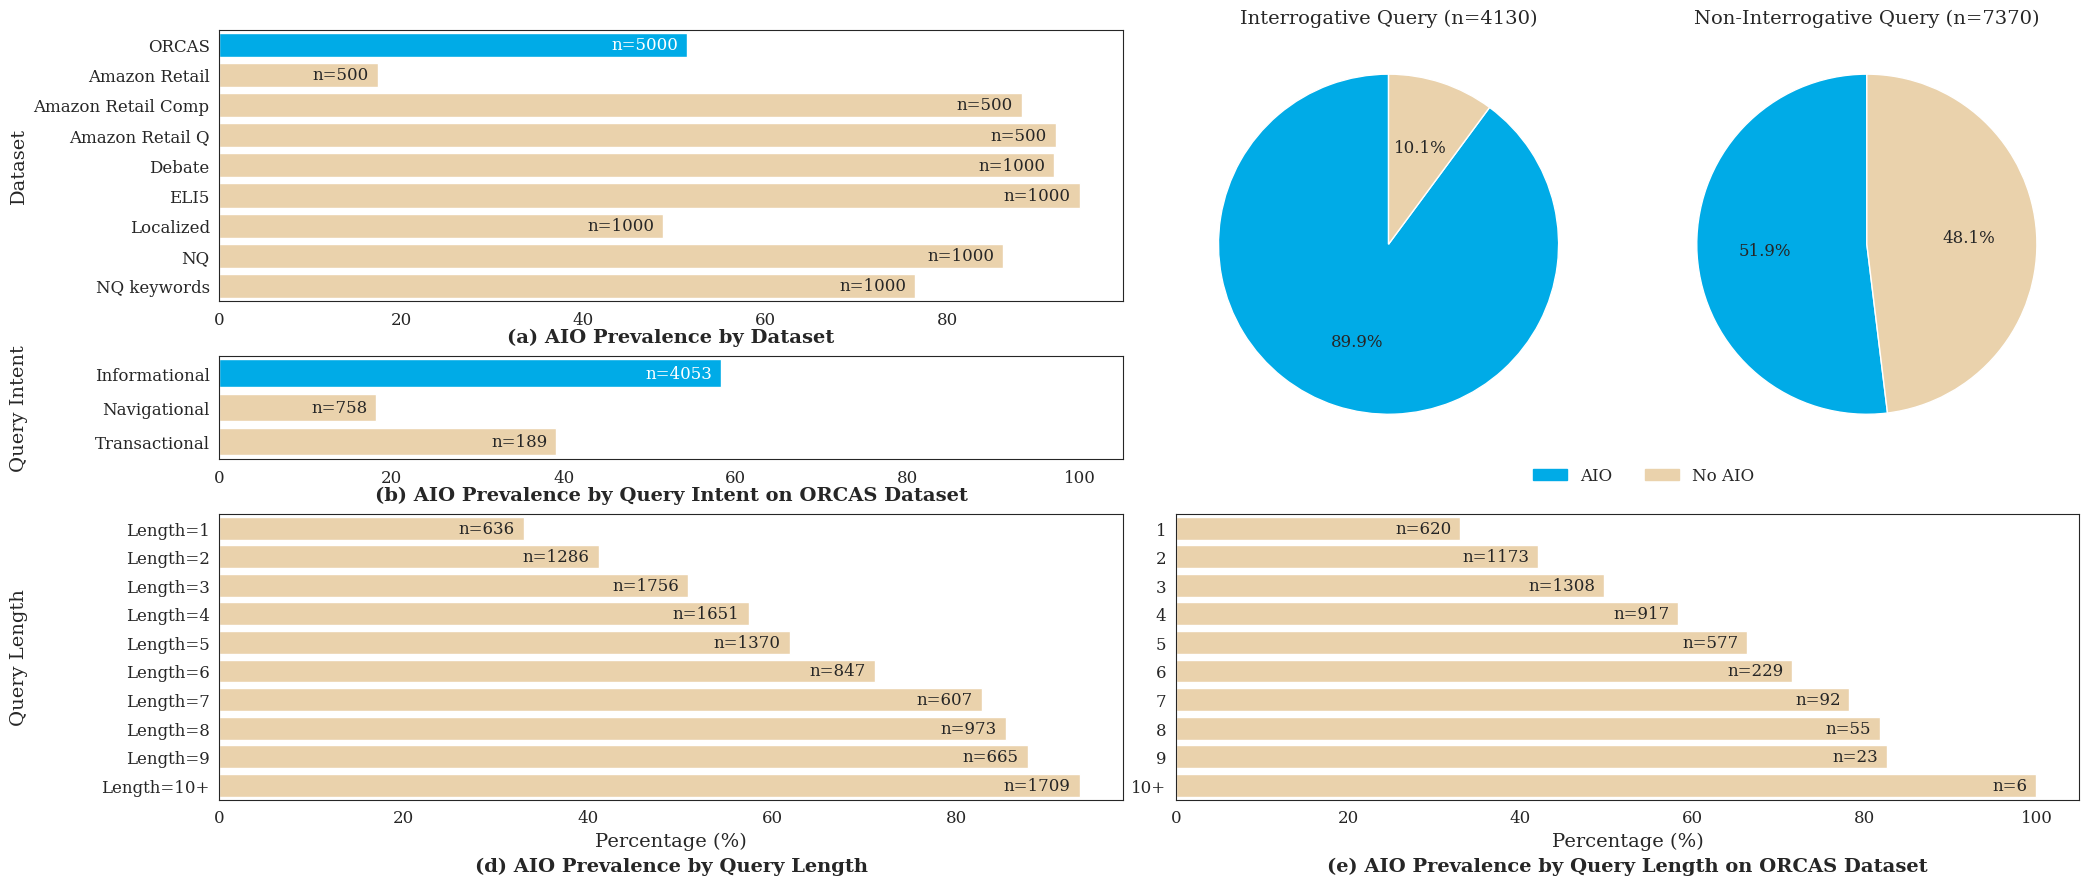

In [266]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import seaborn as sns
from collections import Counter

# palette: https://coolors.co/0081af-00abe7-2dc7ff-ead2ac-eaba6b
base_c = '#EAD2AC'
sec_c = '#00ABE7'
alt_c = '#EAD2AC'
darker_base_c ='#EABA6B'

# --- 1. SETUP & DATA ---
# Use layout="constrained" to manage whitespace automatically
fig = plt.figure(figsize=(24, 10), layout="constrained")

# Define 12 columns. Left plots take 0-6, Right plots take 6-12.
# Increased wspace and hspace for better separation.
gs = gridspec.GridSpec(3, 12, figure=fig, hspace=0.25, wspace=0.5, height_ratios=[0.95, 0.36, 1])

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# --- 2. DEFINE AXES (No manual set_position) ---
ax1 = fig.add_subplot(gs[0, 0:6])   # (a) Top Left
ax2 = fig.add_subplot(gs[1, 0:6])   # (b) Middle Left
ax3 = fig.add_subplot(gs[0:2, 6:9]) # (c) Top Right (Pie 1)
ax3b = fig.add_subplot(gs[0:2, 9:12])# (c) Top Right (Pie 2)
ax4 = fig.add_subplot(gs[2, 0:6])   # (d) Bottom Left
ax5 = fig.add_subplot(gs[2, 6:12])  # (e) Bottom Right

# --- 3. PLOT (a) ---
data = {
    "dataset": ["ORCAS", "Amazon Retail", "Amazon Retail Comp", "Amazon Retail Q", 
                "Debate", "ELI5", "Localized", "NQ", "NQ keywords"],
    "percentage": [51.46, 17.40, 88.20, 92.00, 91.80, 94.60, 48.80, 86.20, 76.50],
}
df2 = pd.DataFrame(data)
sns.barplot(data=df2, x="percentage", y="dataset", palette=[sec_c] + [base_c] * (len(df2) - 1), ax=ax1, saturation=1)
df2 = df2.set_index('dataset')
df2['n'] = [5000, 500, 500, 500, 1000, 1000, 1000, 1000, 1000]
for i, dataset in enumerate(df2.index):
    ax1.text(
        df2.loc[dataset]['percentage'] - 1, i, f"n={df2['n'].loc[dataset]}", va='center', ha='right',
        color=('white' if i == 0 else None)
    )
ax1.set_xlabel("")
ax1.set_ylabel("Dataset")
ax1.text(0.5, -0.15, "(a) AIO Prevalence by Dataset", transform=ax1.transAxes, 
         ha='center', fontweight='bold', fontsize=14)

# --- 4. PLOT (b) ---
# Assuming 'orcas_AIOs_p' and 'orcas_AIOs' exist in your environment
sns.barplot(data=orcas_AIOs_p, x=orcas_AIOs_p.AIO_12_7_8*100, y=orcas_AIOs_p.index, 
            palette=[sec_c, base_c, base_c], ax=ax2, saturation=1)
for i, dataset in enumerate(orcas_AIOs_p.index):
    n_val = orcas_AIOs.loc[dataset]
    ax2.text(
        orcas_AIOs_p.loc[dataset]['AIO_12_7_8']*100 - 1, i, f"n={n_val}", va='center', ha='right',
        color=('white' if i == 0 else None)
    )

ax2.set_xlim(0, 105)
ax2.set_ylabel("Query Intent")
ax2.set_xlabel("")
ax2.text(0.5, -0.4, "(b) AIO Prevalence by Query Intent on ORCAS Dataset", 
         transform=ax2.transAxes, ha='center', fontweight='bold', fontsize=14)

# --- 5. PLOT (c) - PIE CHARTS ---
labels = ['AIO', 'No AIO']
# Data for Interrogative (True) and Non-Interrogative (False)
ax3.pie(vals_true, autopct='%1.1f%%', startangle=90, colors=[sec_c, base_c])
ax3b.pie(vals_false, autopct='%1.1f%%', startangle=90, colors=[sec_c, base_c])

ax3.set_title(f'Interrogative Query (n={len(df_true)})', fontsize=14)
ax3b.set_title(f'Non-Interrogative Query (n={len(df_false)})', fontsize=14)

legend_elements = [plt.Rectangle((0,0),1,1, color=sec_c, label='AIO'),
                   plt.Rectangle((0,0),1,1, color=base_c, label='No AIO')]
ax3.legend(handles=legend_elements, loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(1.1, -0.1))

ax3b.text(0.0, -0.22, "(c) AIO Prevalence by Question Formatting", 
          transform=ax3b.transAxes, ha='center', fontweight='bold', fontsize=14)

# --- 6. PLOT (d) ---
len_AIOs_all = df.groupby('length').mean('AIO_12_7_8')
length_counter = Counter(df.length)
sns.barplot(x=len_AIOs_all.AIO_12_7_8*100, y=len_AIOs_all.index, color=base_c, ax=ax4, saturation=1)

new_labels = [f"Length={i}" for i in len_AIOs_all.index]
ax4.set_yticklabels(new_labels)

for i, val in enumerate(len_AIOs_all.index):
    ax4.text(
        len_AIOs_all.loc[val]['AIO_12_7_8']*100 -1 , i, f"n={length_counter[val]}", va='center', ha='right'
    )

ax4.set_ylabel("Query Length")
ax4.set_xlabel("Percentage (%)")
ax4.text(0.5, -0.25, "(d) AIO Prevalence by Query Length", 
         transform=ax4.transAxes, ha='center', fontweight='bold', fontsize=14)

# --- 7. PLOT (e) ---
orcas_data = df[df.dataset=='ORCAS']
len_AIOs_orcas = orcas_data.groupby('length').mean('AIO_12_7_8')
length_counter_orcas = Counter(orcas_data.length)
sns.barplot(x=len_AIOs_orcas.AIO_12_7_8*100, y=len_AIOs_orcas.index, color=base_c, ax=ax5, saturation=1)

for i, val in enumerate(len_AIOs_orcas.index):
    ax5.text(len_AIOs_orcas.loc[val]['AIO_12_7_8']*100-1, i, f"n={length_counter_orcas[val]}", va='center', ha='right')

ax5.set_ylabel("")
ax5.set_xlabel("Percentage (%)")
ax5.text(0.5, -0.25, "(e) AIO Prevalence by Query Length on ORCAS Dataset", 
         transform=ax5.transAxes, ha='center', fontweight='bold', fontsize=14)

# --- 8. FINAL ALIGNMENT ---
# This forces the vertical spines of the left column to align perfectly
fig.align_ylabels([ax1, ax2, ax4])
# This aligns the right side
fig.align_ylabels([ax3, ax5])

plt.savefig("aligned_five_panel_figure.pdf", bbox_inches="tight")
plt.show()

In [177]:
len(df_false),len(df_true),len(df_false[df_false.AIO_12_7_8==True]),len(df_false[df_false.AIO_12_7_8==False]),len(df_true[df_true.AIO_12_7_8==True]),len(df_true[df_true.AIO_12_7_8==False])

(7370, 4130, 3828, 3542, 3712, 418)

In [178]:
# import pandas as pd
# from scipy.stats import chi2_contingency
# from itertools import combinations

# # 1. Create your Contingency Table
# # Replace this with your actual data counts
# # Format: {Class: [Count_Outcome_0, Count_Outcome_1]}
# data = {
#     'Info': [2361, 1692],
#     'Transactional': [74, 115],
#     'Navigational': [128, 620]
# }

# df_counts = pd.DataFrame(data, index=['AIO', 'No AIO']).T

# # 2. Run the Global Chi-Square Test
# chi2, p_global, dof, expected = chi2_contingency(df_counts)

# print(f"Global P-value: {p_global:.4e},{chi2,dof}")

# # 3. Post-hoc Pairwise Comparisons (Only if Global P is significant)
# if p_global < 0.05:
#     pairs = list(combinations(df_counts.index, 2))
#     alpha = 0.05
#     bonferroni_threshold = alpha / len(pairs) # 0.05 / 3 = 0.0167
    
#     print(f"\nPost-hoc Tests (Significance Threshold: {bonferroni_threshold:.4f})")
#     for p1, p2 in pairs:
#         # Create a 2x2 table for just these two classes
#         subset = df_counts.loc[[p1, p2]]
#         _, p_pair, _, _ = chi2_contingency(subset)
        
#         status = "SIGNIFICANT" if p_pair < bonferroni_threshold else "not significant"
#         print(f"{p1} vs {p2}: p = {p_pair:.4e} ({status})")

In [179]:
# import pandas as pd
# from scipy.stats import chi2_contingency, fisher_exact

# # 1. Define your 2x2 table
# # Format: {Class: [Count_Outcome_0, Count_Outcome_1]}
# #3828, 3542, 3712, 418
# data = {
#     'non-interrogative': [3828, 3542], 
#     'interrogative': [3712, 418]
# }
# df_2x2 = pd.DataFrame(data, index=['Failure (0)', 'Success (1)']).T

# # 2. Run Chi-Square
# chi2, p_chi2, df, _ = chi2_contingency(df_2x2)



# print(f"Chi-Square P-value: {p_chi2:.4e},{chi2,df}")